In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Nyomozás: Hol vagyunk és mik a fájlok?
print(f"1. A Jupyter innen indult: {os.getcwd()}")

# Mik a pontos fájlnevek a te gépeden?
fajl_dtfe = 'DTFE_32/Logfile.dat'
fajl_cic  = 'DTFE_512/Logfile.dat'

# 2. Ellenőrizzük, megvannak-e a mappák és a fájlok!
if not os.path.exists(fajl_dtfe):
    print(f"\nHIBA: Nem találom a DTFE fájlt itt: {fajl_dtfe}")
    if os.path.exists({fajl_dtfe}):
        print(f"A 'BR_original' mappa tartalma: {os.listdir({fajl_dtfe})}")
else:
    print(f"\nSzuper, a DTFE fájl megvan: {fajl_dtfe}")

if not os.path.exists(fajl_cic):
    print(f"HIBA: Nem találom a CIC fájlt itt: {fajl_cic}")
    if os.path.exists({fajl_cic}):
        print(f"A 'BR' mappa tartalma: {os.listdir({fajl_cic})}")
else:
    print(f"Szuper, a CIC fájl megvan: {fajl_cic}")

# 3. Csak akkor rajzolunk, ha mindkét fájl biztonságosan megvan!
if os.path.exists(fajl_dtfe) and os.path.exists(fajl_cic):
    print("\nAdatok beolvasása és rajzolás...")
    oszlop_nevek = ['t', 'ismeretlen', 'h', 'a', 'z', 'H', 'Omega_m_eff', 'a_ratio']
    
    df_dtfe = pd.read_csv(fajl_dtfe, delim_whitespace=True, header=None, names=oszlop_nevek, comment='#')
    df_cic  = pd.read_csv(fajl_cic, delim_whitespace=True, header=None, names=oszlop_nevek, comment='#')
    
    # --- ÁBRA 1: H(z) ---
    plt.figure(figsize=(12, 6))
    plt.plot(df_dtfe['z'], df_dtfe['H'], label=fajl_dtfe, color='blue', lw=2.5)
    plt.plot(df_cic['z'],  df_cic['H'],  label=fajl_cic, color='red', linestyle='--', lw=2.5)
    plt.gca().invert_xaxis()
    plt.xlabel('Vöröseltolódás (z)', fontsize=14)
    plt.ylabel('H(z) [km/s/Mpc]', fontsize=14)
    plt.title('Hubble paraméter (H) evolúciója: DTFE vs. CIC', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

    # --- ÁBRA 2: a(t) ---
    plt.figure(figsize=(12, 6))
    plt.plot(df_dtfe['t'], df_dtfe['a'], label=fajl_dtfe, color='blue', lw=2.5)
    plt.plot(df_cic['t'],  df_cic['a'],  label=fajl_cic, color='red', linestyle='--', lw=2.5)
    plt.xlabel('Kozmikus idő (t) [Gy]', fontsize=14)
    plt.ylabel('Skálafaktor (a)', fontsize=14)
    plt.title('Univerzum mérete az időben a(t)', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()
else:
    print("\n--- RAJZOLÁS LEÁLLÍTVA --- \nKérlek, nézd meg a fenti hibaüzeneteket, és írd át a fájlneveket a kód elején arra, amit a mappákban talált a Python!")

1. A Jupyter innen indult: /v/szalkaidora/avera

HIBA: Nem találom a DTFE fájlt itt: DTFE_32/Logfile.dat


TypeError: stat: path should be string, bytes, os.PathLike or integer, not set

A Jupyter innen indult: /v/szalkaidora/avera

Adatok beolvasása...
  OK: LCDM_standard/Logfile.dat betöltve.
  OK: CIC_32/Logfile.dat betöltve.
  OK: CIC_96/Logfile.dat betöltve.
  OK: CIC_100/Logfile.dat betöltve.
  OK: resolutions_LCDM_IC_HSTART1191_100Mpc_135k_s08159_IC_LCDM/Logfile.dat betöltve.

Grafikonok generálása...


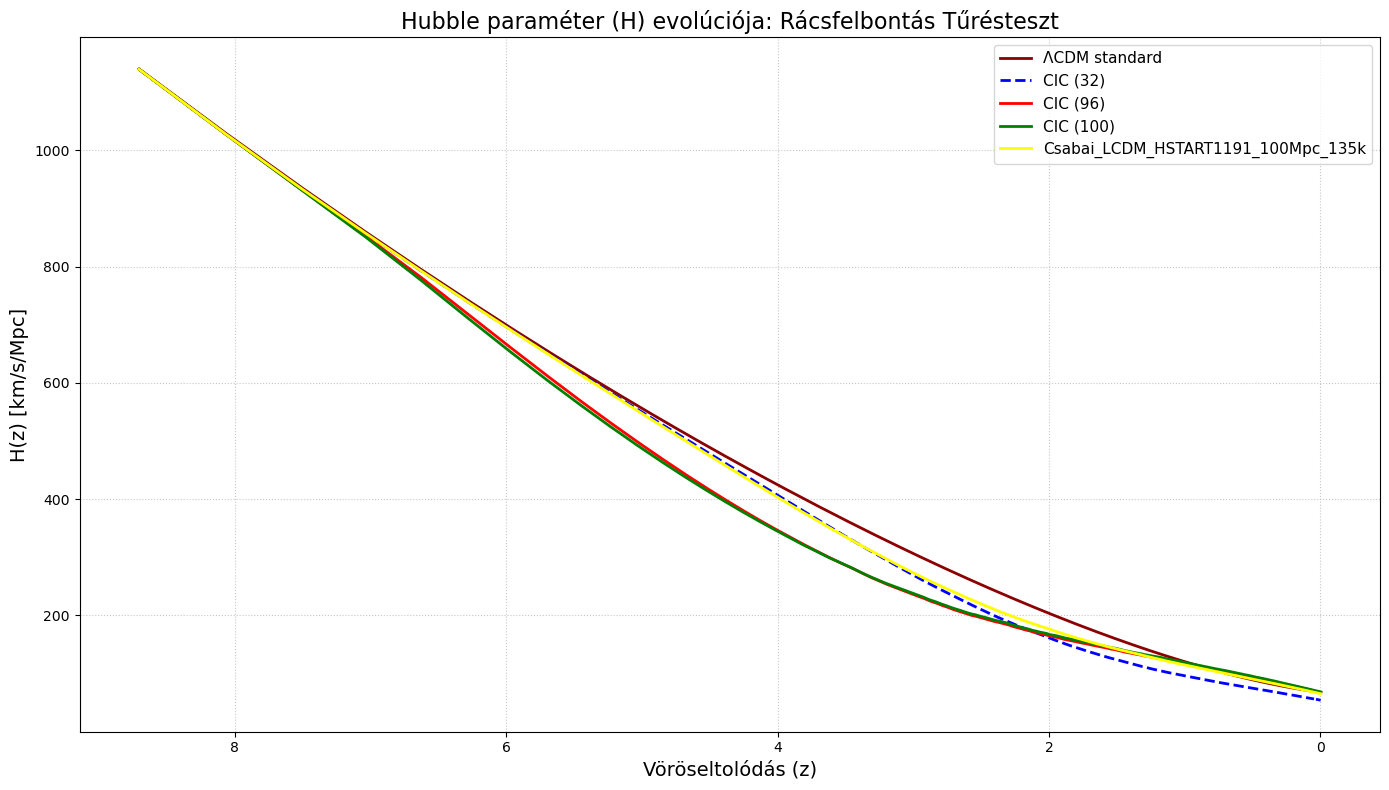

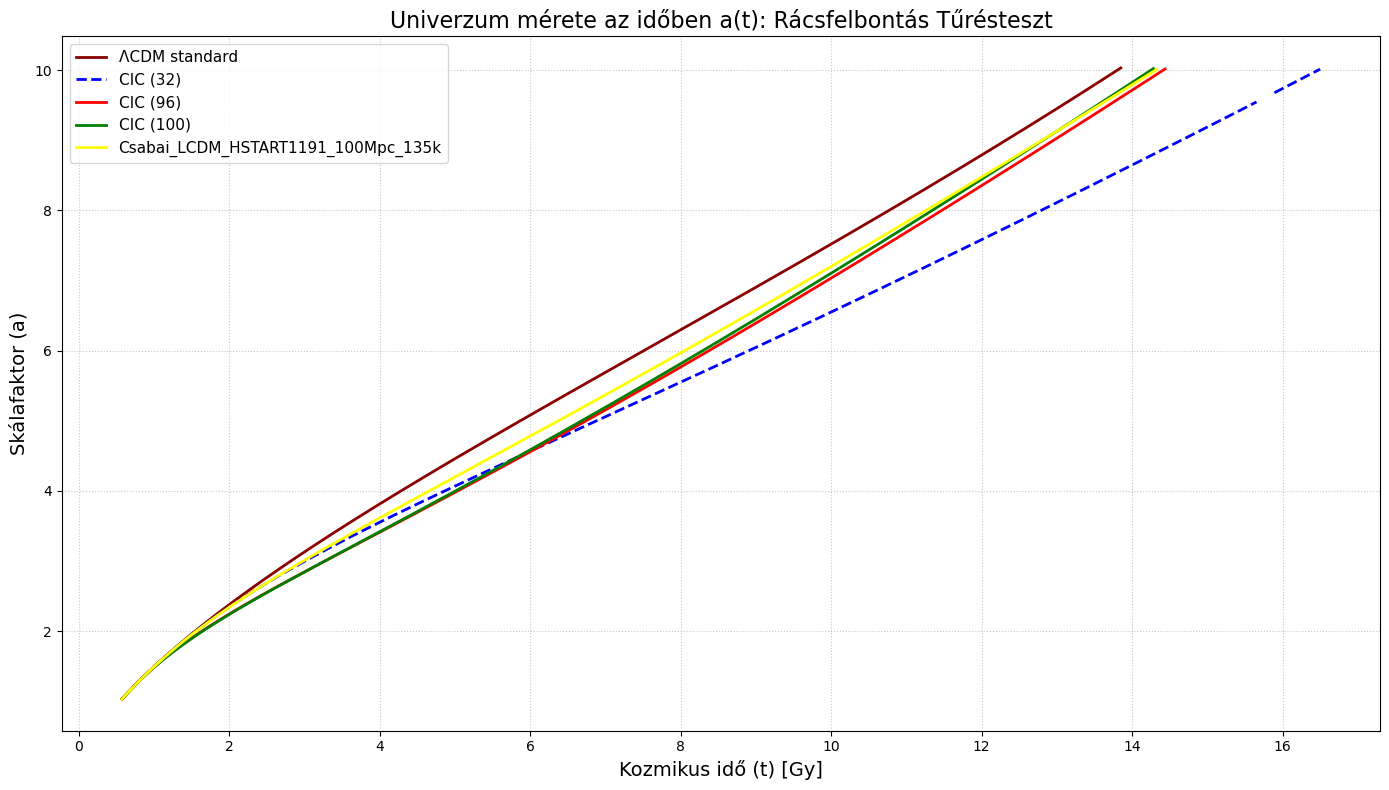

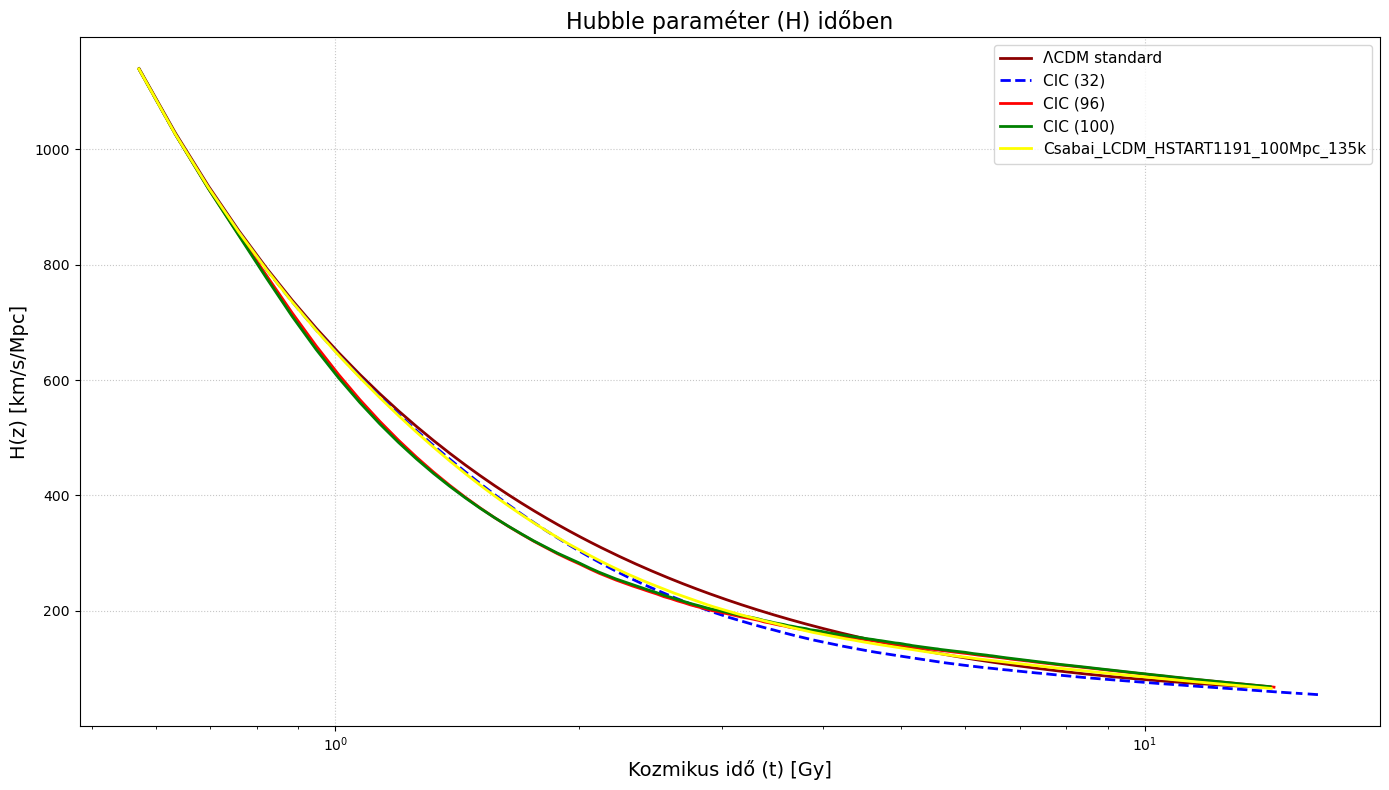


Kész!


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definiáljuk a mappákat és a stílusokat
# Kulcs: Mappa neve (ahol a Logfile.dat van)
# Érték: (Szín, Vonalstílus, Címke az ábrán)
run_styles = {
   # 'LCDM':       ('gold', '-',  'ΛCDM Referencia'),
   # 'LCDM_withsigma_256': ('darkred', '-',  'ΛCDM sigmaval'),
    'LCDM_standard': ('darkred', '-',  'ΛCDM standard'),
    
   # 'CIC_64':     ('red',  '-.', 'CIC (64)'),
    'CIC_32':    ('blue',  '--', 'CIC (32)'),
    'CIC_96':    ('red',  '-',  'CIC (96)'),
    'CIC_100':    ('green', '-', 'CIC (100)'), # Sötétebb piros, hogy elváljon a 256-ostól
    'resolutions_LCDM_IC_HSTART1191_100Mpc_135k_s08159_IC_LCDM' : ('yellow', '-', 'Csabai_LCDM_HSTART1191_100Mpc_135k'),
   # 'DTFE':    ('blue', ':',  'DTFE'),
    #'DTFE_128_147_625k': ('blue', ':',  'Voro 128'),
    #'DTFE_64':    ('blue', '-.', 'DTFE (64)'),
    #'DTFE_128':   ('blue', '--', 'DTFE (128)'),
    #'CIC_128':   ('green', '--',  'CIC(128)'),
    #'voro':     ('black', '-',  'VORO')
    #'DTFE_512':   ('darkblue', '-', 'DTFE (512)') # Sötétebb kék

   
}

oszlop_nevek = ['t', 'ismeretlen', 'h', 'a', 'z', 'H', 'Omega_m_eff', 'a_ratio']
dataframes = {}

print(f"A Jupyter innen indult: {os.getcwd()}")
print("\nAdatok beolvasása...")

# 2. Végigmegyünk a definiált mappákon és beolvassuk a logokat
for folder, style_info in run_styles.items():
    file_path = os.path.join(folder, 'Logfile.dat')
    
    if os.path.exists(file_path):
        print(f"  OK: {file_path} betöltve.")
        try:
            df = pd.read_csv(file_path, delim_whitespace=True, header=None, names=oszlop_nevek, comment='#')
            dataframes[folder] = df
        except Exception as e:
            print(f"  HIBA a {file_path} olvasásakor: {e}")
    else:
        print(f"  HIÁNYZIK: {file_path} nem található, kihagyom a rajzolásból.")

# 3. Rajzolás
if not dataframes:
    print("\nHIBA: Egyetlen adatfájlt sem sikerült beolvasni. Ellenőrizd a mappák helyét!")
else:
    print("\nGrafikonok generálása...")

    # --- ÁBRA 1: H(z) ---
    plt.figure(figsize=(14, 8))
    for folder, df in dataframes.items():
        color, linestyle, label = run_styles[folder]
        # A vonalvastagságot a sárga (LCDM) esetén kicsit nagyobbra vesszük, hogy jól látszódjon
        lw = 3.5 if folder == 'LCDM' else 2.0 
        # LCDM-et kicsit előtérbe hozzuk (zorder)
        zo = 10 if folder == 'LCDM' else 5
        
        plt.plot(df['z'], df['H'], label=label, color=color, linestyle=linestyle, lw=lw, zorder=zo)

    plt.gca().invert_xaxis()
    plt.xlabel('Vöröseltolódás (z)', fontsize=14)
    plt.ylabel('H(z) [km/s/Mpc]', fontsize=14)
    plt.title('Hubble paraméter (H) evolúciója: Rácsfelbontás Tűrésteszt', fontsize=16)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    #plt.xlim(0, 9)
    #plt.ylim(62, 1200)
    plt.tight_layout()
    plt.show()

    # --- ÁBRA 2: a(t) ---
    plt.figure(figsize=(14, 8))
    for folder, df in dataframes.items():
        color, linestyle, label = run_styles[folder]
        lw = 3.5 if folder == 'LCDM' else 2.0
        zo = 10 if folder == 'LCDM' else 5
        
        plt.plot(df['t'], df['a'], label=label, color=color, linestyle=linestyle, lw=lw, zorder=zo)

    plt.xlabel('Kozmikus idő (t) [Gy]', fontsize=14)
    plt.ylabel('Skálafaktor (a)', fontsize=14)
    plt.title('Univerzum mérete az időben a(t): Rácsfelbontás Tűrésteszt', fontsize=16)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

 # --- ÁBRA 3: H(z) ---
    plt.figure(figsize=(14, 8))
    for folder, df in dataframes.items():
        color, linestyle, label = run_styles[folder]
        lw = 3.5 if folder == 'LCDM' else 2.0
        zo = 10 if folder == 'LCDM' else 5
        
        plt.plot(df['t'], df['H'], label=label, color=color, linestyle=linestyle, lw=lw, zorder=zo)

    plt.xlabel('Kozmikus idő (t) [Gy]', fontsize=14)
    plt.ylabel('H(z) [km/s/Mpc]', fontsize=14)
    plt.xscale('log')
    plt.title('Hubble paraméter (H) időben', fontsize=16)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("\nKész!")